# 10. CVAE Layer Training — PyTorch

torso / legs / feet / hair 4개 카테고리를 대상으로 `{category}_{keyword}` 레이블로 CVAE를 학습.

| 항목 | 값 |
|------|----|
| 대상 카테고리 | torso, legs, feet, hair |
| 총 클래스 수 | 86 |
| 총 파일 수 | ~906,787 |
| 레이블 형식 | `{category}_{keyword}` (예: torso_clothes, feet_boots) |
| 아키텍처 | CVAE (08-1과 동일, n_classes만 변경) |
| 체크포인트 | `checkpoints_cvae_layer_pt/` |

## Section 1 — 환경 설정

In [1]:
import os, json, random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split

# fix working directory
_root = Path(os.path.abspath(''))
for _p in [_root] + list(_root.parents):
    if (_p / 'dataset' / 'processed').exists():
        os.chdir(_p); break
print(f'CWD: {Path.cwd()}')

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

CWD: /Users/gomuseo/Desktop/Python/vae_test
Device: mps


## Section 2 — CFG

In [2]:
PROCESSED  = Path('dataset/processed')
CKPT_DIR   = Path('checkpoints_cvae_layer_pt')
CKPT_DIR.mkdir(exist_ok=True)

CATEGORIES = ['torso', 'legs', 'feet', 'hair']

# 클래스당 최대 파일 수 — None이면 전체 사용
# 전체 학습 시 ~12시간, 5000으로 제한 시 ~1시간
MAX_PER_CLASS = 2000

CFG = {
    'latent_dim'   : 128,
    'base_channels': 32,
    'channels'     : 4,
    'epochs'       : 100,
    'batch_size'   : 128,
    'lr'           : 1e-3,
    'beta'         : 1.5,
    'patience'     : 10,
    'max_per_class': MAX_PER_CLASS,
    'categories'   : CATEGORIES,
}

LATENT_DIM = CFG['latent_dim']
BASE_CH    = CFG['base_channels']
CHANNELS   = CFG['channels']
EPOCHS     = CFG['epochs']
BATCH_SIZE = CFG['batch_size']
LR         = CFG['lr']
BETA       = CFG['beta']
PATIENCE   = CFG['patience']

print('CFG:', json.dumps(CFG, indent=2))

CFG: {
  "latent_dim": 128,
  "base_channels": 32,
  "channels": 4,
  "epochs": 100,
  "batch_size": 128,
  "lr": 0.001,
  "beta": 1.5,
  "patience": 10,
  "max_per_class": 2000,
  "categories": [
    "torso",
    "legs",
    "feet",
    "hair"
  ]
}


## Section 3 — 레이블 맵 생성

`{category}_{keyword}` 형태로 레이블을 구성하고 인덱스를 부여.

In [3]:
label_list = []  # (path, label_idx)
label_names = []  # idx → label_name
label_map = {}   # label_name → idx

for cat in CATEGORIES:
    cat_dir = PROCESSED / cat
    for kw_dir in sorted(cat_dir.iterdir()):
        if not kw_dir.is_dir():
            continue
        label_name = f'{cat}_{kw_dir.name}'
        label_map[label_name] = len(label_names)
        label_names.append(label_name)

NUM_CLASSES = len(label_names)
CFG['num_classes'] = NUM_CLASSES
print(f'Total classes: {NUM_CLASSES}')
print()

# 파일 수집
all_paths, all_labels = [], []

for cat in CATEGORIES:
    cat_dir = PROCESSED / cat
    for kw_dir in sorted(cat_dir.iterdir()):
        if not kw_dir.is_dir():
            continue
        label_name = f'{cat}_{kw_dir.name}'
        idx = label_map[label_name]
        files = sorted(kw_dir.glob('*.png'))
        if MAX_PER_CLASS:
            files = files[:MAX_PER_CLASS]
        cnt = len(files)
        all_paths.extend([str(f) for f in files])
        all_labels.extend([idx] * cnt)
        print(f'  {label_name}: {cnt:,}')

print(f'\nTotal files: {len(all_paths):,}')

# config 저장 (label_map 포함)
CFG['label_map']     = label_map
CFG['label_names']   = label_names
with open(CKPT_DIR / 'config.json', 'w') as f:
    json.dump(CFG, f, indent=2, ensure_ascii=False)

Total classes: 86

  torso_aprons: 2,000
  torso_armour: 2,000
  torso_bandage: 534
  torso_chainmail: 472
  torso_clothes: 2,000
  torso_jacket: 2,000
  torso_waist: 2,000
  legs_armour: 470
  legs_cuffed: 2,000
  legs_formal: 2,000
  legs_fur: 2,000
  legs_hose: 2,000
  legs_leggings: 2,000
  legs_leggings2: 2,000
  legs_pantaloons: 2,000
  legs_pants: 2,000
  legs_pants2: 2,000
  legs_shorts: 2,000
  legs_skirts: 2,000
  feet_accessory: 2,000
  feet_armour: 2,000
  feet_boots: 2,000
  feet_hoofs: 2,000
  feet_sandals: 2,000
  feet_shoes: 2,000
  feet_slippers: 2,000
  feet_socks: 2,000
  hair_afro: 352
  hair_balding: 352
  hair_bangs: 704
  hair_bangslong: 352
  hair_bangslong2: 516
  hair_bangsshort: 352
  hair_bedhead: 352
  hair_bob: 704
  hair_braid: 1,445
  hair_braid2: 523
  hair_bunches: 611
  hair_buzzcut: 352
  hair_cornrows: 352
  hair_cowlick: 704
  hair_curls: 2,000
  hair_curly: 1,056
  hair_curtains: 704
  hair_dreadlocks: 704
  hair_extensions: 2,000
  hair_flat: 1,0

## Section 4 — 클래스 분포 시각화

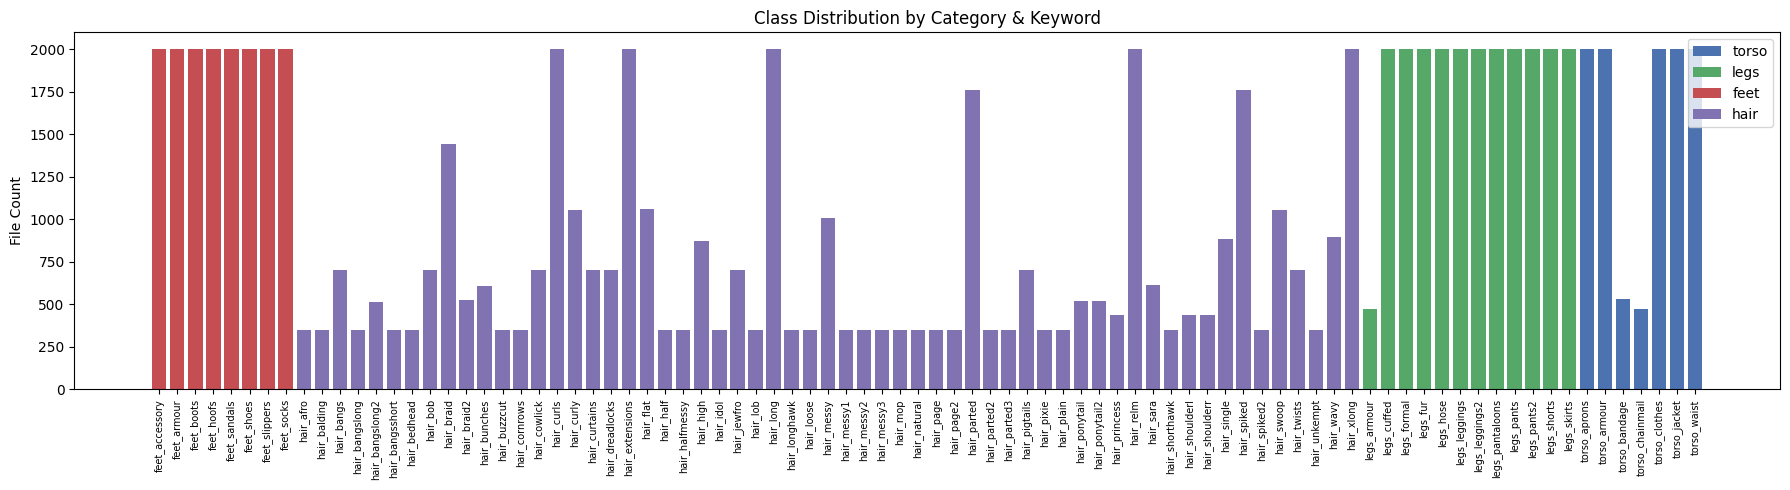

In [4]:
counts = Counter(all_labels)
sorted_counts = sorted(counts.items(), key=lambda x: label_names[x[0]])

cat_colors = {'torso': '#4C72B0', 'legs': '#55A868', 'feet': '#C44E52', 'hair': '#8172B2'}
colors = [cat_colors[label_names[idx].split('_')[0]] for idx, _ in sorted_counts]

fig, ax = plt.subplots(figsize=(18, 5))
x_pos = range(len(sorted_counts))
bars = ax.bar(x_pos, [v for _, v in sorted_counts], color=colors)
ax.set_xticks(list(x_pos))
ax.set_xticklabels([label_names[idx] for idx, _ in sorted_counts],
                   rotation=90, fontsize=7)
ax.set_ylabel('File Count')
ax.set_title('Class Distribution by Category & Keyword')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=cat) for cat, c in cat_colors.items()]
ax.legend(handles=legend_elements)
plt.tight_layout()

OUT_DIR = Path('output/10_cvae_layer_pytorch')
OUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT_DIR / 'figure_01_class_distribution.png', dpi=100)
plt.show()

## Section 5 — 데이터셋 준비

In [5]:
class SpriteDataset(Dataset):
    def __init__(self, paths, labels, num_classes):
        self.paths       = paths
        self.labels      = labels
        self.num_classes = num_classes
        self.transform   = transforms.ToTensor()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = self.transform(Image.open(self.paths[idx]).convert('RGBA'))
        c   = F.one_hot(torch.tensor(self.labels[idx]), self.num_classes).float()
        return img, c


tr_paths, vl_paths, tr_labels, vl_labels = train_test_split(
    all_paths, all_labels, test_size=0.1, random_state=42, stratify=all_labels
)
print(f'Train: {len(tr_paths):,}  Val: {len(vl_paths):,}')

train_ds = SpriteDataset(tr_paths, tr_labels, NUM_CLASSES)
val_ds   = SpriteDataset(vl_paths, vl_labels, NUM_CLASSES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, drop_last=False)
print(f'Train batches: {len(train_loader):,}  Val batches: {len(val_loader):,}')
print(f'Estimated time/epoch (70ms/step): {len(train_loader)*70/1000/60:.1f} min')

Train: 81,927  Val: 9,104
Train batches: 640  Val batches: 72
Estimated time/epoch (70ms/step): 0.7 min


## Section 6 — CVAE 모델

08-1과 동일한 아키텍처, `num_classes`만 86으로 변경.

In [6]:
class CVAEEncoder(nn.Module):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        layers, in_ch, ch = [], channels, base_ch
        for _ in range(4):
            layers += [nn.Conv2d(in_ch, ch, 4, stride=2, padding=1),
                       nn.BatchNorm2d(ch, momentum=0.1),
                       nn.LeakyReLU(0.2)]
            in_ch = ch; ch *= 2
        self.conv  = nn.Sequential(*layers)
        flat_dim   = (base_ch * 8) * 4 * 4
        self.fc_mu = nn.Linear(flat_dim + num_classes, latent_dim)
        self.fc_lv = nn.Linear(flat_dim + num_classes, latent_dim)

    def forward(self, x, c):
        h = self.conv(x).flatten(1)
        h = torch.cat([h, c], dim=-1)
        return self.fc_mu(h), self.fc_lv(h)


class CVAEDecoder(nn.Module):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        self.start_ch = base_ch * 8
        self.fc       = nn.Linear(latent_dim + num_classes, self.start_ch * 4 * 4)
        layers, in_ch = [], self.start_ch
        for i, out_ch in enumerate([base_ch*4, base_ch*2, base_ch, channels]):
            layers.append(nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1))
            if i < 3:
                layers += [nn.BatchNorm2d(out_ch, momentum=0.1), nn.ReLU()]
            else:
                layers.append(nn.Sigmoid())
            in_ch = out_ch
        self.deconv = nn.Sequential(*layers)

    def forward(self, z, c):
        h = self.fc(torch.cat([z, c], dim=-1))
        return self.deconv(h.view(-1, self.start_ch, 4, 4))


class CVAE(nn.Module):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        self.encoder = CVAEEncoder(num_classes, base_ch, latent_dim, channels)
        self.decoder = CVAEDecoder(num_classes, base_ch, latent_dim, channels)

    def forward(self, x, c):
        mu, lv = self.encoder(x, c)
        z      = mu + torch.randn_like(mu) * torch.exp(0.5 * lv)
        return self.decoder(z, c), mu, lv


model = CVAE(NUM_CLASSES, BASE_CH, LATENT_DIM, CHANNELS).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')
print(f'NUM_CLASSES: {NUM_CLASSES}')

Parameters: 3,333,956
NUM_CLASSES: 86


## Section 7 — 학습

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)


def compute_loss(recon, x, mu, lv, beta):
    batch      = x.size(0)
    recon_loss = F.mse_loss(recon, x, reduction='sum') / batch
    kl_loss    = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / batch
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


history      = {'loss': [], 'val_loss': [], 'recon': [], 'kl': []}
best_val     = float('inf')
patience_cnt = 0

for epoch in range(EPOCHS):
    model.train()
    tr_loss = tr_recon = tr_kl = 0.0
    for x, c in train_loader:
        x, c = x.to(DEVICE), c.to(DEVICE)
        recon, mu, lv = model(x, c)
        loss, r, k = compute_loss(recon, x, mu, lv, BETA)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tr_loss += loss.item(); tr_recon += r.item(); tr_kl += k.item()
    n = len(train_loader)
    tr_loss /= n; tr_recon /= n; tr_kl /= n

    model.eval()
    vl_loss = 0.0
    with torch.no_grad():
        for x, c in val_loader:
            x, c = x.to(DEVICE), c.to(DEVICE)
            recon, mu, lv = model(x, c)
            loss, _, _ = compute_loss(recon, x, mu, lv, BETA)
            vl_loss += loss.item()
    vl_loss /= max(len(val_loader), 1)

    scheduler.step()
    history['loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['recon'].append(tr_recon)
    history['kl'].append(tr_kl)

    print(f'Epoch {epoch+1:>3}/{EPOCHS}  '
          f'loss={tr_loss:.2f}  recon={tr_recon:.2f}  kl={tr_kl:.2f}  '
          f'val={vl_loss:.2f}  lr={scheduler.get_last_lr()[0]:.2e}')

    if vl_loss < best_val:
        best_val = vl_loss
        patience_cnt = 0
        torch.save(model.state_dict(), CKPT_DIR / 'best.pt')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

torch.save(model.state_dict(), CKPT_DIR / 'final.pt')
model.load_state_dict(torch.load(CKPT_DIR / 'best.pt', map_location=DEVICE))
print(f'\nBest val_loss: {best_val:.4f}')

Epoch   1/100  loss=220.84  recon=203.60  kl=11.49  val=104.85  lr=1.00e-03
Epoch   2/100  loss=96.86  recon=78.09  kl=12.51  val=88.45  lr=9.99e-04
Epoch   3/100  loss=83.31  recon=64.71  kl=12.40  val=77.60  lr=9.98e-04
Epoch   4/100  loss=74.88  recon=56.29  kl=12.40  val=70.51  lr=9.96e-04
Epoch   5/100  loss=69.45  recon=51.43  kl=12.01  val=66.82  lr=9.94e-04
Epoch   6/100  loss=66.14  recon=48.29  kl=11.90  val=64.08  lr=9.91e-04
Epoch   7/100  loss=63.14  recon=45.67  kl=11.65  val=61.99  lr=9.88e-04
Epoch   8/100  loss=61.28  recon=43.88  kl=11.60  val=60.45  lr=9.84e-04
Epoch   9/100  loss=59.19  recon=41.98  kl=11.47  val=58.75  lr=9.80e-04
Epoch  10/100  loss=57.68  recon=40.60  kl=11.38  val=57.03  lr=9.76e-04
Epoch  11/100  loss=56.34  recon=39.38  kl=11.31  val=55.51  lr=9.71e-04
Epoch  12/100  loss=55.16  recon=38.26  kl=11.27  val=54.99  lr=9.65e-04
Epoch  13/100  loss=54.17  recon=37.35  kl=11.21  val=54.29  lr=9.59e-04
Epoch  14/100  loss=53.48  recon=36.65  kl=11.22

## Section 8 — 학습 곡선

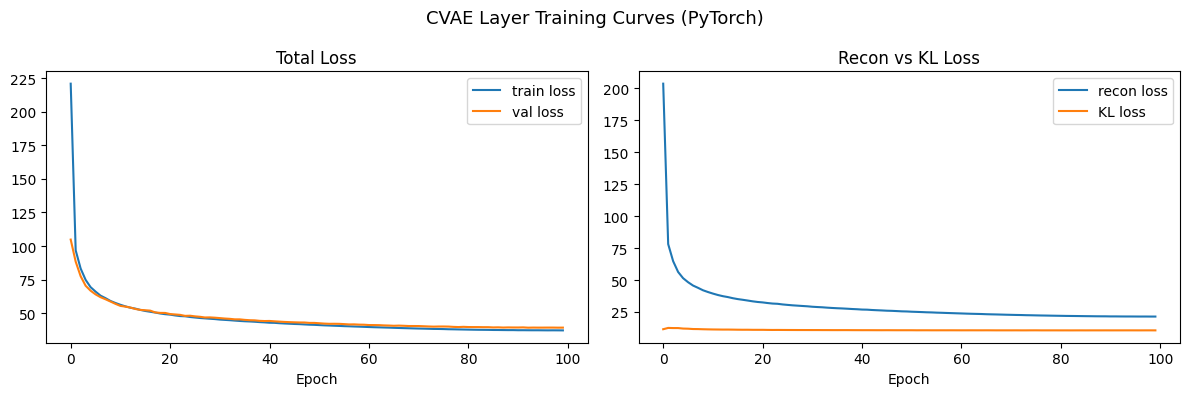

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['loss'],     label='train loss')
axes[0].plot(history['val_loss'], label='val loss')
axes[0].set_title('Total Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['recon'], label='recon loss')
axes[1].plot(history['kl'],    label='KL loss')
axes[1].set_title('Recon vs KL Loss'); axes[1].legend(); axes[1].set_xlabel('Epoch')

plt.suptitle('CVAE Layer Training Curves (PyTorch)', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figure_02_training_curves.png', dpi=100)
plt.show()

## Section 9 — 복원 결과 확인

카테고리별 샘플 복원 결과를 확인.

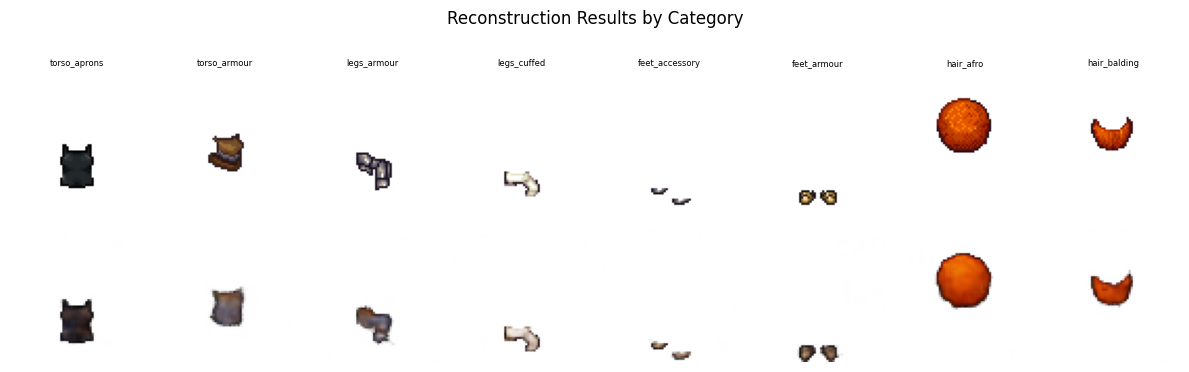

In [9]:
def composite(t):
    t = np.array(t)
    rgb, a = t[..., :3], t[..., 3:4]
    return rgb * a + np.ones_like(rgb) * (1 - a)


model.eval()
# 각 카테고리에서 2개씩 샘플
sample_paths, sample_lbls = [], []
for cat in CATEGORIES:
    cat_dir = PROCESSED / cat
    kw_dirs = sorted(d for d in cat_dir.iterdir() if d.is_dir())
    picked  = kw_dirs[:2]
    for kw_dir in picked:
        files = sorted(kw_dir.glob('*.png'))
        if files:
            sample_paths.append(str(files[0]))
            sample_lbls.append(label_map[f'{cat}_{kw_dir.name}'])

N = len(sample_paths)
transform = transforms.ToTensor()
imgs = torch.stack([transform(Image.open(p).convert('RGBA')) for p in sample_paths]).to(DEVICE)
cs   = torch.stack([F.one_hot(torch.tensor(l), NUM_CLASSES).float() for l in sample_lbls]).to(DEVICE)

with torch.no_grad():
    recons, _, _ = model(imgs, cs)

imgs   = imgs.cpu().permute(0, 2, 3, 1).numpy()
recons = recons.cpu().permute(0, 2, 3, 1).numpy()

fig, axes = plt.subplots(2, N, figsize=(N * 1.5, 4))
for i in range(N):
    lbl = label_names[sample_lbls[i]]
    axes[0, i].imshow(composite(imgs[i]))
    axes[0, i].set_title(lbl, fontsize=6)
    axes[0, i].axis('off')
    axes[1, i].imshow(composite(recons[i]))
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('Recon',    fontsize=9)
plt.suptitle('Reconstruction Results by Category', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figure_03_reconstruction.png', dpi=100)
plt.show()

## Section 10 — 조건부 생성 테스트

동일한 z에서 카테고리별 대표 키워드로 생성.

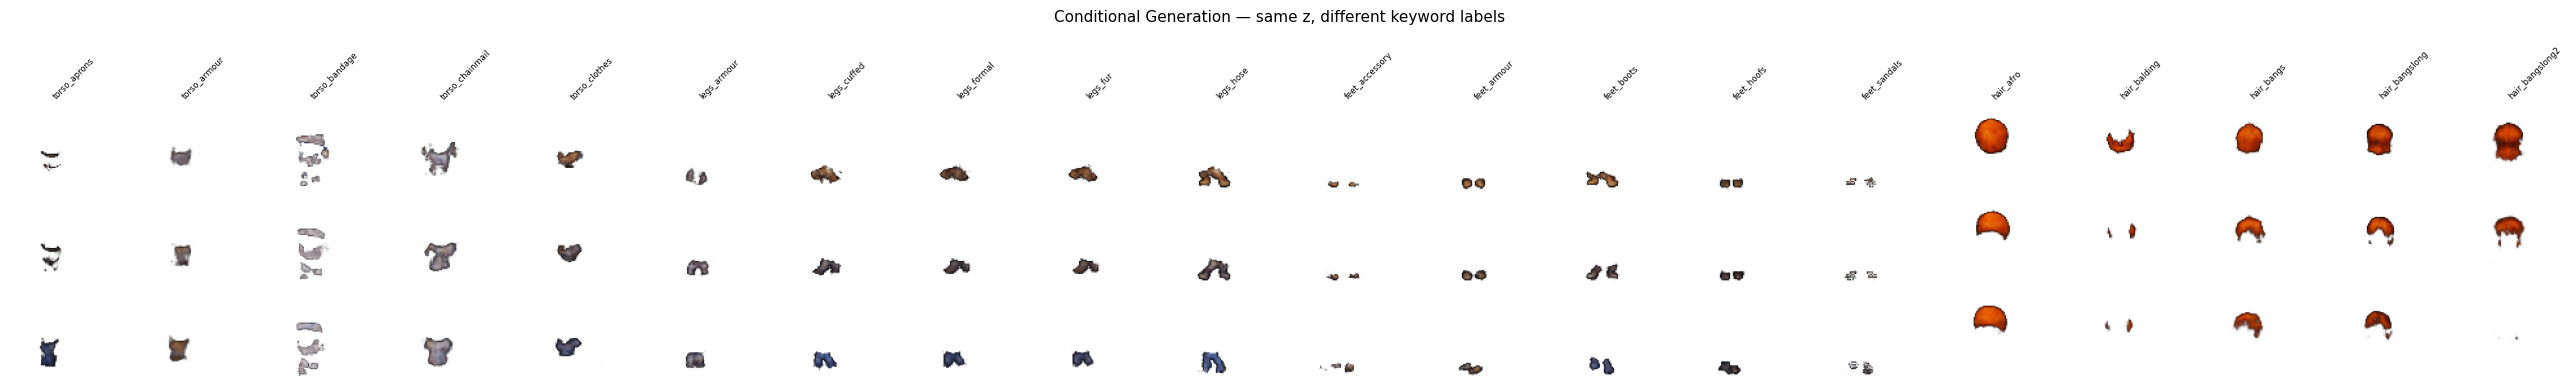

In [10]:
# 카테고리별 대표 키워드 선택 (첫 번째 알파벳순)
rep_labels = {}
for cat in CATEGORIES:
    cat_dir = PROCESSED / cat
    kw_dirs = sorted(d for d in cat_dir.iterdir() if d.is_dir())
    for kw_dir in kw_dirs[:5]:  # 카테고리별 최대 5개
        name = f'{cat}_{kw_dir.name}'
        rep_labels[name] = label_map[name]

label_list_show = list(rep_labels.items())
N_COLS = len(label_list_show)
N_ROWS = 3

torch.manual_seed(42)
z_samples = torch.randn(N_ROWS, LATENT_DIM).to(DEVICE)

model.eval()
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 1.3, N_ROWS * 1.3))

with torch.no_grad():
    for row in range(N_ROWS):
        for col, (lbl_name, lbl_idx) in enumerate(label_list_show):
            c   = F.one_hot(torch.tensor([lbl_idx]), NUM_CLASSES).float().to(DEVICE)
            img = model.decoder(z_samples[row].unsqueeze(0), c)
            img = img[0].cpu().permute(1, 2, 0).numpy()
            axes[row, col].imshow(composite(img))
            axes[row, col].axis('off')
            if row == 0:
                axes[row, col].set_title(lbl_name, fontsize=6, rotation=45, ha='left')

plt.suptitle('Conditional Generation — same z, different keyword labels', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figure_04_conditional_generation.png', dpi=100)
plt.show()